In [1]:

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

import warnings
warnings.filterwarnings("ignore")

In [3]:
columns = ['engine_id','cycle',
           'setting1','setting2','setting3',
           's1','s2','s3','s4','s5','s6','s7','s8','s9','s10',
           's11','s12','s13','s14','s15','s16','s17','s18','s19','s20','s21']

In [4]:
train = pd.read_csv("train_FD001.txt", sep=" ", header=None)
train = train.drop(columns=[26,27])
train.columns = columns

train.head()

,engine_id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
test = pd.read_csv("test_FD001.txt", sep=" ", header=None)
test = test.drop(columns=[26,27])
test.columns = columns

In [6]:
rul = pd.read_csv("RUL_FD001.txt", header=None)
rul.columns = ["RUL"]

In [7]:
train.shape

(20631, 26)

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   engine_id  20631 non-null  int64  
 1   cycle      20631 non-null  int64  
 2   setting1   20631 non-null  float64
 3   setting2   20631 non-null  float64
 4   setting3   20631 non-null  float64
 5   s1         20631 non-null  float64
 6   s2         20631 non-null  float64
 7   s3         20631 non-null  float64
 8   s4         20631 non-null  float64
 9   s5         20631 non-null  float64
 10  s6         20631 non-null  float64
 11  s7         20631 non-null  float64
 12  s8         20631 non-null  float64
 13  s9         20631 non-null  float64
 14  s10        20631 non-null  float64
 15  s11        20631 non-null  float64
 16  s12        20631 non-null  float64
 17  s13        20631 non-null  float64
 18  s14        20631 non-null  float64
 19  s15        20631 non-null  float64
 20  s16   

In [9]:
train.describe()

,engine_id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [10]:
train['engine_id'].nunique()

100

In [59]:
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()

max_cycle.columns = ['engine_id','max_cycle']

train = train.merge(max_cycle,on='engine_id')

train['RUL'] = train['max_cycle'] - train['cycle']

train['RUL'] = train['RUL'].clip(upper=125)

train.drop(columns=['max_cycle'], inplace=True)

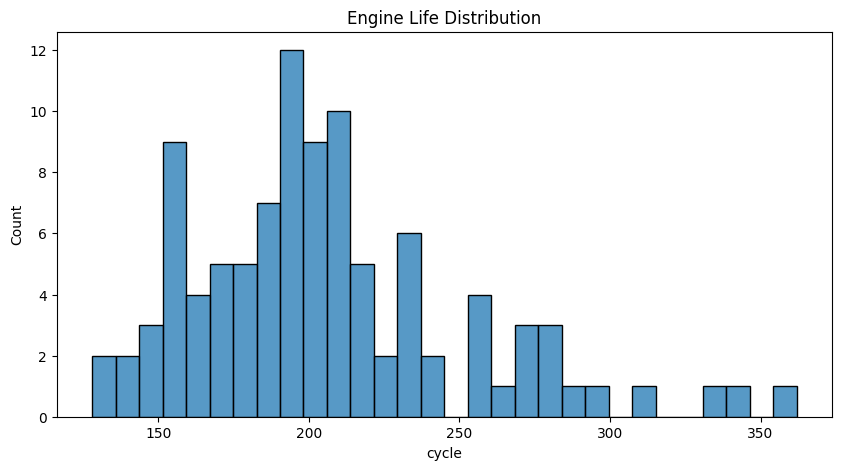

In [41]:
engine_life = train.groupby('engine_id')['cycle'].max()

plt.figure(figsize=(10,5))
sns.histplot(engine_life, bins=30)

plt.title("Engine Life Distribution")

plt.show()

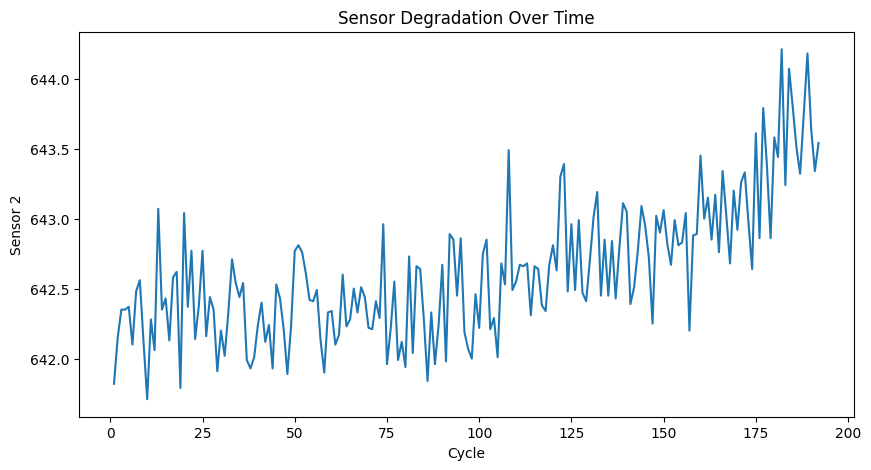

In [13]:
engine1 = train[train['engine_id']==1]

plt.figure(figsize=(10,5))

plt.plot(engine1['cycle'], engine1['s2'])

plt.xlabel("Cycle")
plt.ylabel("Sensor 2")

plt.title("Sensor Degradation Over Time")

plt.show()

In [42]:
drop_sensors = ['s1','s5','s6','s10','s16','s18','s19']

train = train.drop(columns=drop_sensors)
test = test.drop(columns=drop_sensors)

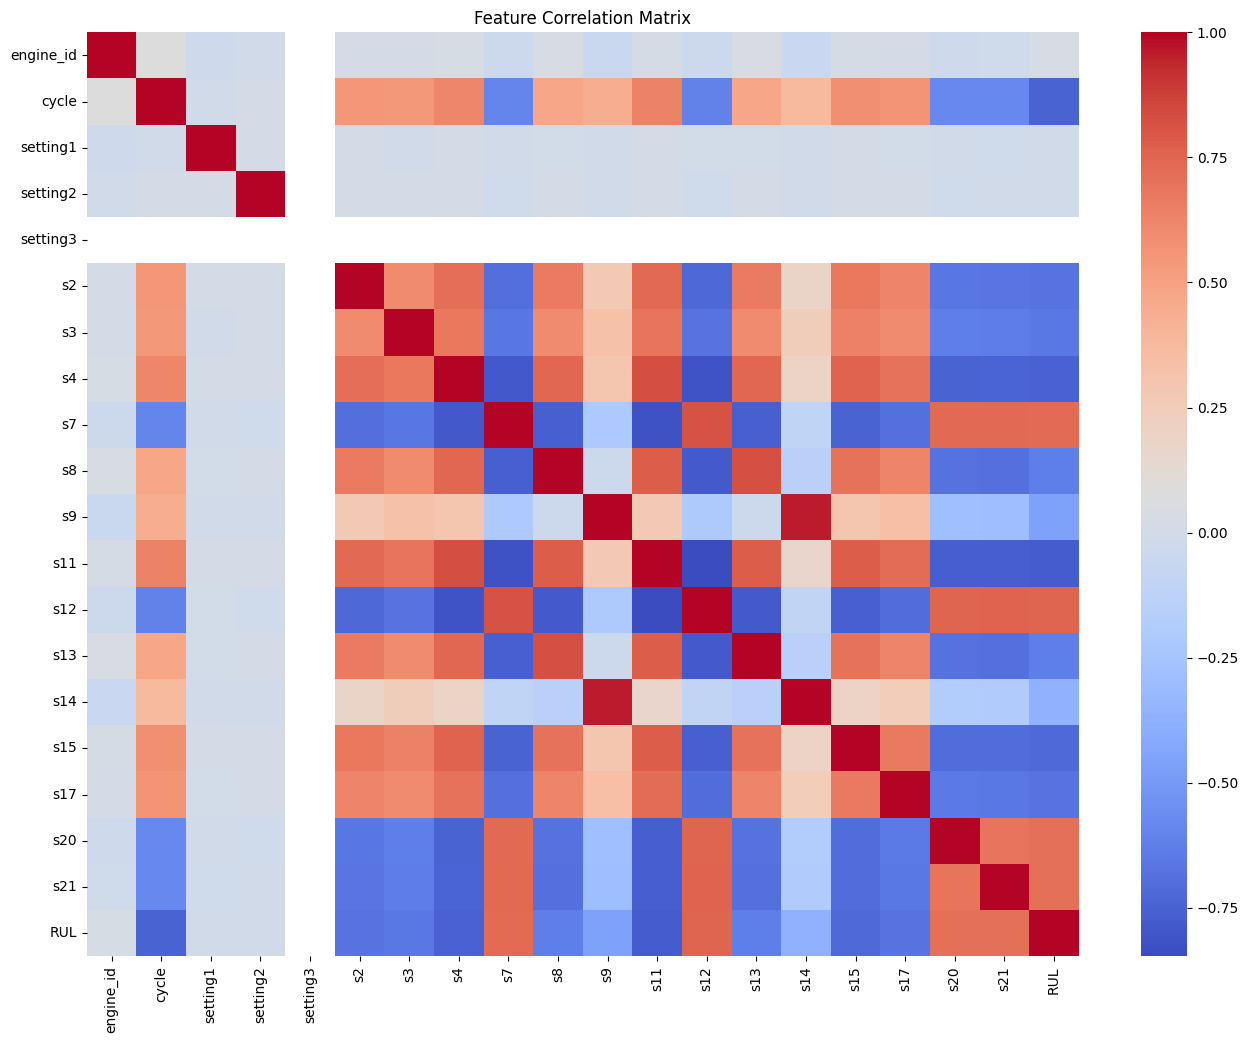

In [43]:
plt.figure(figsize=(16,12))

sns.heatmap(train.corr(), cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

In [60]:
scaler = MinMaxScaler()

sensor_cols = [
's2','s3','s4','s7','s8','s9',
's11','s12','s13','s14','s15',
's17','s20','s21'
]

settings = ['setting1','setting2','setting3']

features = settings + sensor_cols
train[features] = scaler.fit_transform(train[features])

test[features] = scaler.transform(test[features])

In [61]:
X = train[sensor_cols]
y = train['RUL']

In [62]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [63]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
pred = rf.predict(X_val)

In [65]:
rmse = np.sqrt(mean_squared_error(y_val, pred))

print("Random Forest RMSE:", rmse)

Random Forest RMSE: 18.57368715031961


In [66]:
sequence_length = 30

In [67]:
def create_sequences(features, target, seq_length):

    X_seq = []
    y_seq = []

    for i in range(len(features) - seq_length):

        X_seq.append(features[i:i+seq_length])
        y_seq.append(target[i+seq_length])  

    return np.array(X_seq), np.array(y_seq)

In [68]:
sensor_data = train[features].values
target = train['RUL'].values

X_seq, y_seq = create_sequences(sensor_data, target, sequence_length)

In [69]:
split = int(0.8 * len(X_seq))

X_train = X_seq[:split]
X_test = X_seq[split:]

y_train = y_seq[:split]
y_test = y_seq[split:]

In [70]:
model = Sequential()

model.add(LSTM(128, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.3))

model.add(LSTM(64))

model.add(Dropout(0.3))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

In [71]:
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 6589.6450 - val_loss: 5970.1675
Epoch 2/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 4902.3555 - val_loss: 4576.2153
Epoch 3/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 3797.7478 - val_loss: 3577.8792
Epoch 4/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 3026.2200 - val_loss: 2883.2373
Epoch 5/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 2508.7439 - val_loss: 2418.0347
Epoch 6/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 2181.2092 - val_loss: 2119.1853
Epoch 7/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1994.6273 - val_loss: 1938.5200
Epoch 8/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1883.9004 - val_loss: 1834.0862
Epoch 9/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1838.9170 - val_loss: 1777.8431
Epoch 10/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1818.4849 - val_loss: 1748.3174
Epoch 11/40
206/206 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1791.60

In [72]:
lstm_pred = model.predict(X_test)
lstm_pred = lstm_pred.flatten()

rmse_lstm = np.sqrt(mean_squared_error(y_test, lstm_pred))

print("LSTM RMSE:", rmse_lstm)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step   
LSTM RMSE: 15.098813931196922


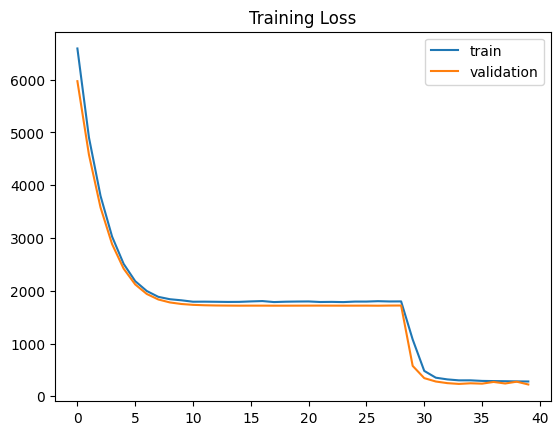

In [73]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training Loss")

plt.legend(['train','validation'])

plt.show()

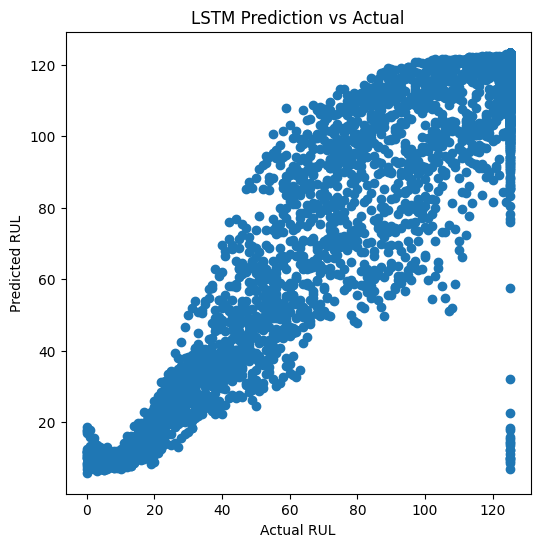

In [74]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, lstm_pred)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title("LSTM Prediction vs Actual")

plt.show()

In [76]:
model.save("turbofan_lstm_model.keras")

In [77]:
print("Final LSTM RMSE:", rmse_lstm)

Final LSTM RMSE: 15.098813931196922


In [78]:
sample = X_test[0].reshape(1, X_test.shape[1], X_test.shape[2])

prediction = model.predict(sample)

print("Predicted RUL:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted RUL: 93.30872


In [79]:
print("Actual RUL:", y_test[0])
print("Predicted RUL:", int(prediction[0][0]))

Actual RUL: 81
Predicted RUL: 93


In [80]:
for i in range(10):

    sample = X_test[i].reshape(1, X_test.shape[1], X_test.shape[2])

    pred = model.predict(sample)

    print("Actual:", y_test[i], " Predicted:", int(pred[0][0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Actual: 81  Predicted: 93
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Actual: 80  Predicted: 92
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Actual: 79  Predicted: 83
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Actual: 78  Predicted: 86
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Actual: 77  Predicted: 84
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Actual: 76  Predicted: 82
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Actual: 75  Predicted: 80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Actual: 74  Predicted: 83
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Actual: 73  Predicted: 80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Actual: 72  Predicted: 77


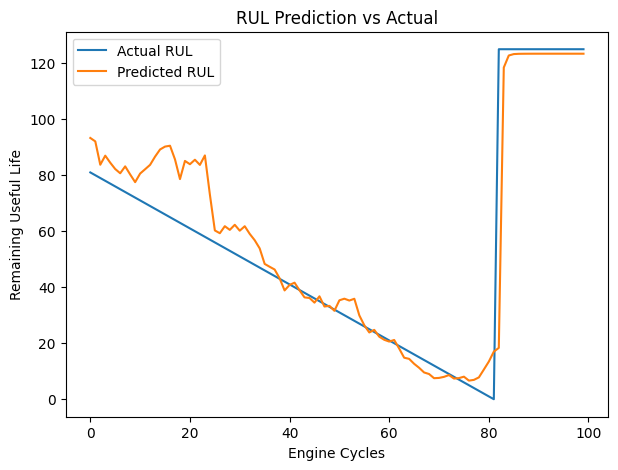

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(y_test[:100], label="Actual RUL")
plt.plot(lstm_pred[:100], label="Predicted RUL")

plt.legend()

plt.title("RUL Prediction vs Actual")

plt.xlabel("Engine Cycles")
plt.ylabel("Remaining Useful Life")

plt.show()

In [83]:
max_rul = 125

predicted_rul = prediction[0][0]

health_score = (predicted_rul / max_rul) * 100

print("Predicted RUL:", int(predicted_rul))
print("Engine Health Score:", round(health_score,2), "%")
if health_score > 75:
    status = "Healthy"

elif health_score > 50:
    status = "Moderate Condition"

elif health_score > 25:
    status = "Warning"

else:
    status = "Critical - Maintenance Needed"

print("Engine Status:", status)

Predicted RUL: 93
Engine Health Score: 74.65 %
Engine Status: Moderate Condition


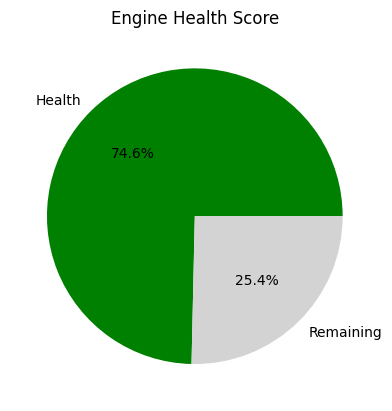

In [84]:
import matplotlib.pyplot as plt

labels = ['Health','Remaining']

sizes = [health_score, 100-health_score]

plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        colors=['green','lightgray'])

plt.title("Engine Health Score")

plt.show()